In [3]:
!pip install moviepy

In [4]:
import moviepy
print(moviepy.__version__)

1.0.3


In [5]:
from google.colab import files
uploaded = files.upload()

Saving kapalbhati.mp3 to kapalbhati.mp3


In [6]:
!ffmpeg -version

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-l

In [7]:
!ls

kapalbhati.mp3	sample_data


In [10]:
!ffmpeg -y -i "kapalbhati.mp3" -vn -acodec pcm_s16le -ar 44100 -ac 1 AV_01.wav

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [11]:

import librosa
import matplotlib.pyplot as plt

# Load audio
y, sr = librosa.load("AV_01.wav", sr=None)

print("Sample Rate :", sr)
print("Duration :", librosa.get_duration(y=y, sr=sr))
print("Total Samples :", len(y))

Sample Rate : 44100
Duration : 59.904013605442174
Total Samples : 2641767


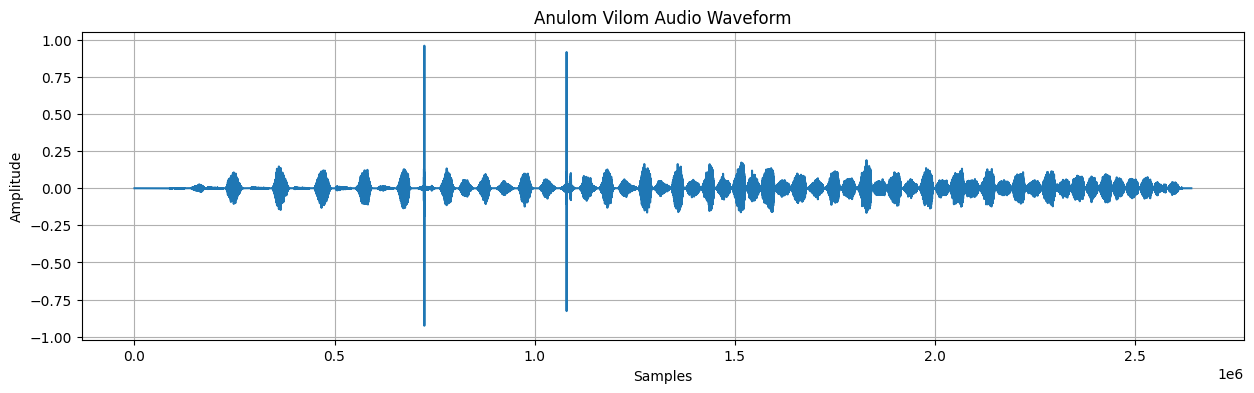

In [12]:
plt.figure(figsize=(15,4))
plt.plot(y)

plt.title("Anulom Vilom Audio Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid(True)

plt.show()

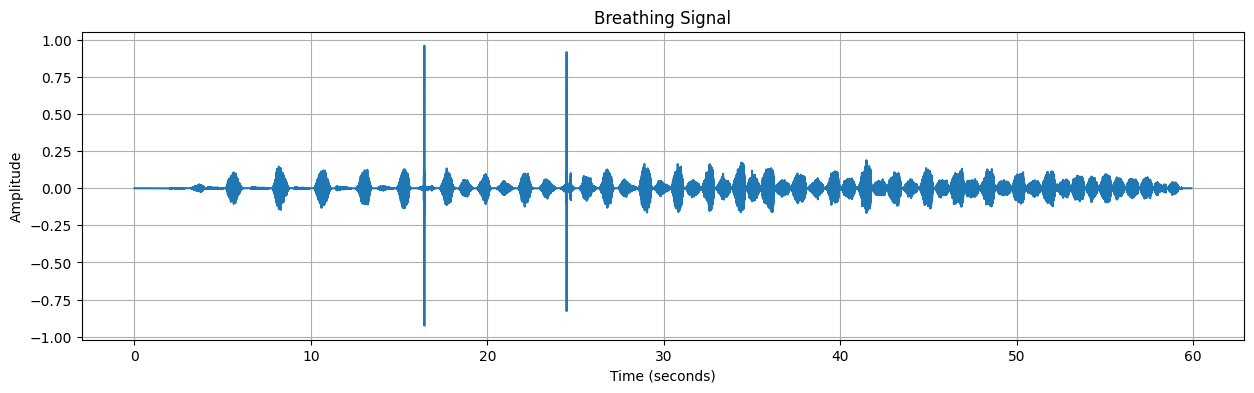

In [13]:

import numpy as np

time = np.linspace(0, len(y)/sr, len(y))

plt.figure(figsize=(15,4))
plt.plot(time, y)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Breathing Signal")

plt.grid()

plt.show()

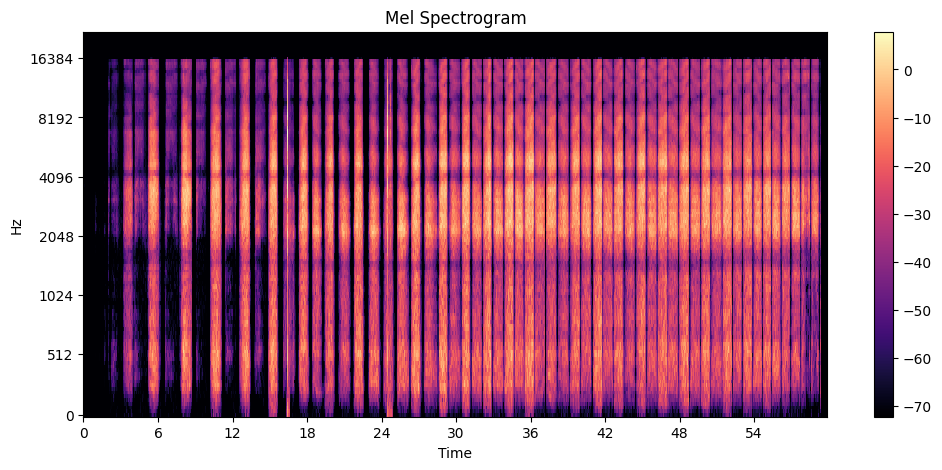

In [14]:

import librosa.display

mel = librosa.feature.melspectrogram(y=y, sr=sr)

mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

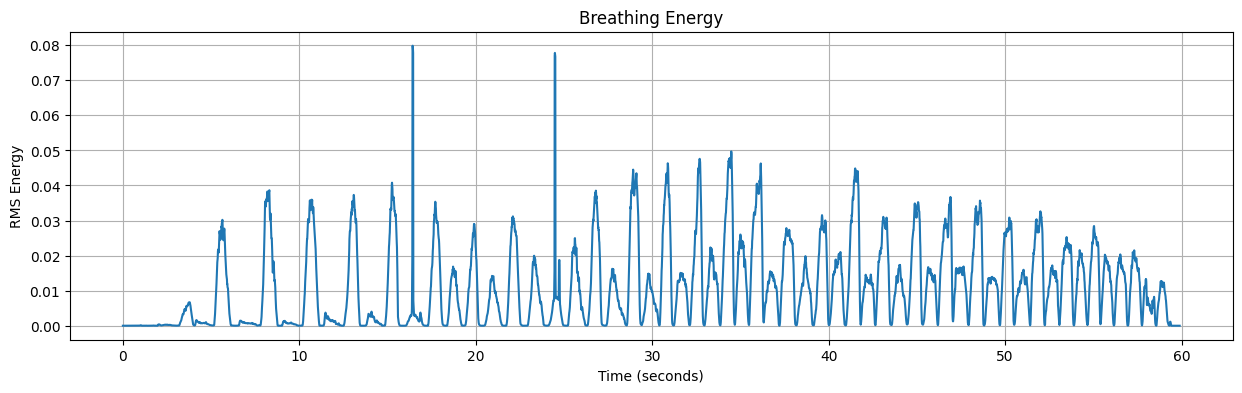

In [15]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

y, sr = librosa.load("AV_01.wav", sr=None)

frame_length = 2048
hop_length = 512

rms = librosa.feature.rms(
    y=y,
    frame_length=frame_length,
    hop_length=hop_length
)[0]

times = librosa.times_like(
    rms,
    sr=sr,
    hop_length=hop_length
)

plt.figure(figsize=(15,4))
plt.plot(times, rms)

plt.xlabel("Time (seconds)")
plt.ylabel("RMS Energy")

plt.title("Breathing Energy")

plt.grid()

plt.show()



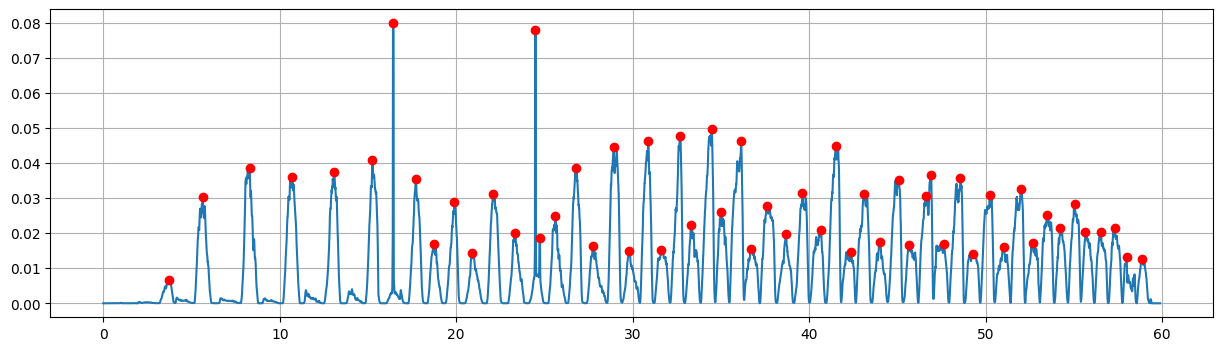

Detected peaks: 55


In [16]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(
    rms,
    distance=20,
    prominence=0.005
)

plt.figure(figsize=(15,4))
plt.plot(times, rms)
plt.plot(times[peaks], rms[peaks], "ro")

plt.grid()
plt.show()

print("Detected peaks:", len(peaks))

In [17]:

duration = librosa.get_duration(y=y, sr=sr)

breathing_rate = len(peaks) * 60 / duration

print("Estimated Breaths per Minute:", breathing_rate)

Estimated Breaths per Minute: 55.08812851398326


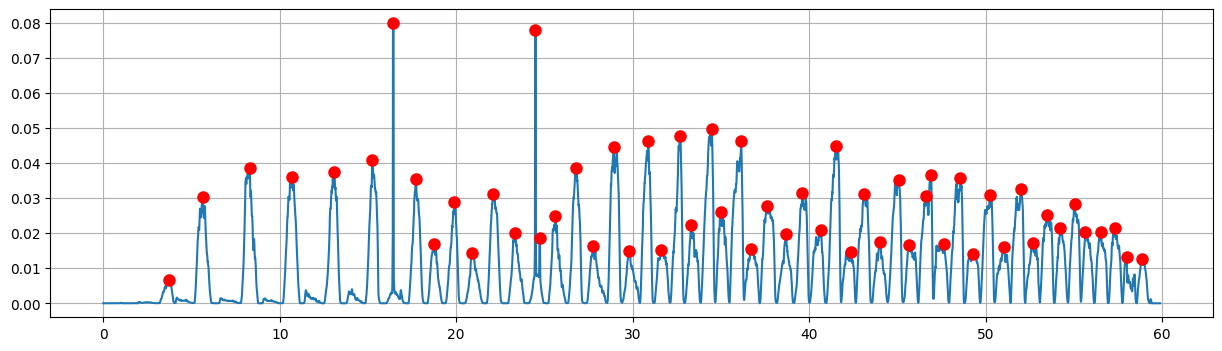

In [18]:
plt.figure(figsize=(15,4))

plt.plot(times, rms)

plt.plot(times[peaks], rms[peaks], "ro", markersize=8)

plt.grid()

plt.show()

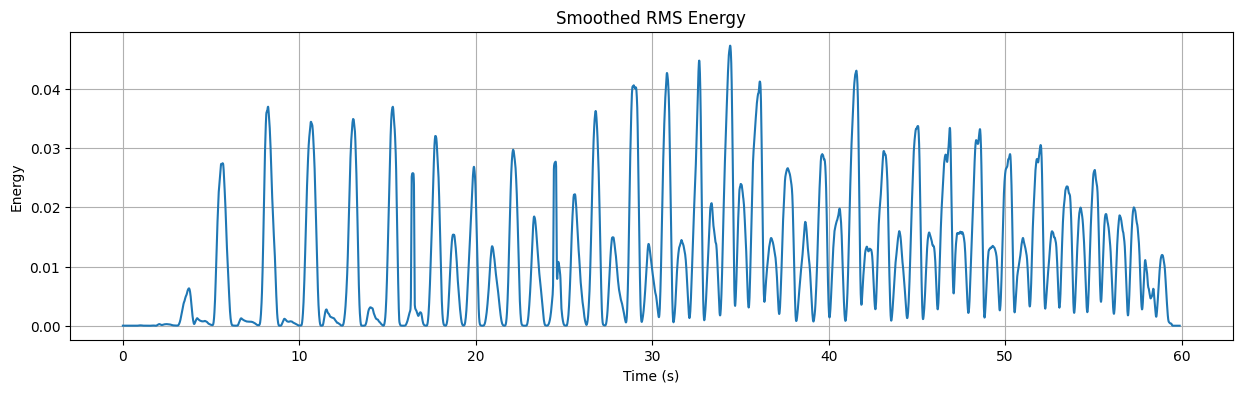

In [19]:
import numpy as np

window_size = 15
rms_smooth = np.convolve(rms, np.ones(window_size)/window_size, mode='same')

plt.figure(figsize=(15,4))
plt.plot(times, rms_smooth)
plt.title("Smoothed RMS Energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.grid()
plt.show()

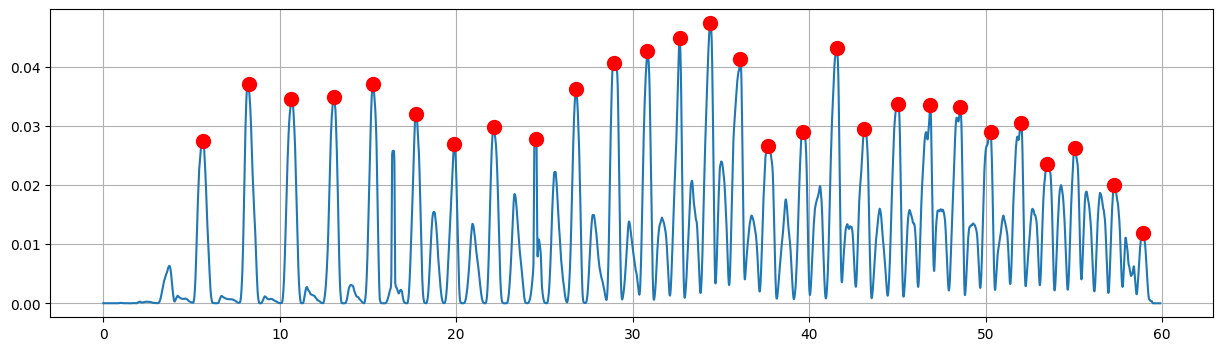

Number of Peaks: 28


In [20]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    rms_smooth,
    distance=120,
    prominence=0.01
)

plt.figure(figsize=(15,4))
plt.plot(times, rms_smooth)
plt.plot(times[peaks], rms_smooth[peaks], "ro", markersize=10)

plt.grid()
plt.show()

print("Number of Peaks:", len(peaks))

In [21]:
duration = librosa.get_duration(y=y, sr=sr)

breathing_rate = len(peaks) * 60 / duration

print("Estimated Breaths per Minute:", breathing_rate)

Estimated Breaths per Minute: 28.044865425300568


In [22]:

print("Total Breathing Cycles :", len(peaks))

Total Breathing Cycles : 28


In [23]:
peak_times = times[peaks]

print(peak_times)

[ 5.65405896  8.23147392 10.65795918 13.04961451 15.30195011 17.7168254
 19.89950113 22.1170068  24.53188209 26.79582766 28.95528345 30.83609977
 32.67047619 34.41197279 36.0954195  37.68598639 39.64807256 41.5753288
 43.11945578 45.058322   46.86947846 48.57614512 50.28281179 52.01269841
 53.48716553 55.07773243 57.2952381  58.89741497]


In [24]:
cycle_duration = np.diff(peak_times)

print(cycle_duration)

[2.57741497 2.42648526 2.39165533 2.2523356  2.41487528 2.18267574
 2.21750567 2.41487528 2.26394558 2.15945578 1.88081633 1.83437642
 1.7414966  1.68344671 1.59056689 1.96208617 1.92725624 1.54412698
 1.93886621 1.81115646 1.70666667 1.70666667 1.72988662 1.47446712
 1.59056689 2.21750567 1.60217687]


In [27]:
avg_cycle = np.mean(cycle_duration)

print("Average Cycle Duration =", avg_cycle)

Average Cycle Duration = 1.971976148484085


In [28]:

breathing_rate = 60 / avg_cycle

print("Breathing Frequency =", breathing_rate)

Breathing Frequency = 30.426331498037506


In [29]:
std_cycle = np.std(cycle_duration)

print("Rhythm Consistency (STD) =", std_cycle)

Rhythm Consistency (STD) = 0.3194827204901141


In [30]:

print("Maximum Cycle =", np.max(cycle_duration))

Maximum Cycle = 2.577414965986395


In [31]:
print("Minimum Cycle =", np.min(cycle_duration))

Minimum Cycle = 1.4744671201814086


In [32]:
print("Average RMS =", np.mean(rms_smooth))

Average RMS = 0.0114052256766475


In [33]:
print("Maximum RMS =", np.max(rms_smooth))

Maximum RMS = 0.047315083692471185


In [34]:

import pandas as pd

results = pd.DataFrame({
    "Parameter": [
        "Duration (s)",
        "Detected Peaks",
        "Breathing Frequency (breaths/min)",
        "Average Cycle Duration (s)",
        "Rhythm Consistency (STD)",
        "Maximum Cycle Duration (s)",
        "Minimum Cycle Duration (s)",
        "Average RMS Energy",
        "Maximum RMS Energy"
    ],
    "Value": [
        librosa.get_duration(y=y, sr=sr),
        len(peak_times),
        breathing_rate,
        avg_cycle,
        std_cycle,
        np.max(cycle_duration),
        np.min(cycle_duration),
        np.mean(rms_smooth),
        np.max(rms_smooth)
    ]
})

results

,Parameter,Value
0,Duration (s),59.904014
1,Detected Peaks,28.000000
2,Breathing Frequency (breaths/min),30.426331
3,Average Cycle Duration (s),1.971976
4,Rhythm Consistency (STD),0.319483
5,Maximum Cycle Duration (s),2.577415
6,Minimum Cycle Duration (s),1.474467
7,Average RMS Energy,0.011405
8,Maximum RMS Energy,0.047315


In [36]:

results.to_csv("Quantitative_Results.csv", index=False)


In [37]:
print(cycle_duration)

[2.57741497 2.42648526 2.39165533 2.2523356  2.41487528 2.18267574
 2.21750567 2.41487528 2.26394558 2.15945578 1.88081633 1.83437642
 1.7414966  1.68344671 1.59056689 1.96208617 1.92725624 1.54412698
 1.93886621 1.81115646 1.70666667 1.70666667 1.72988662 1.47446712
 1.59056689 2.21750567 1.60217687]


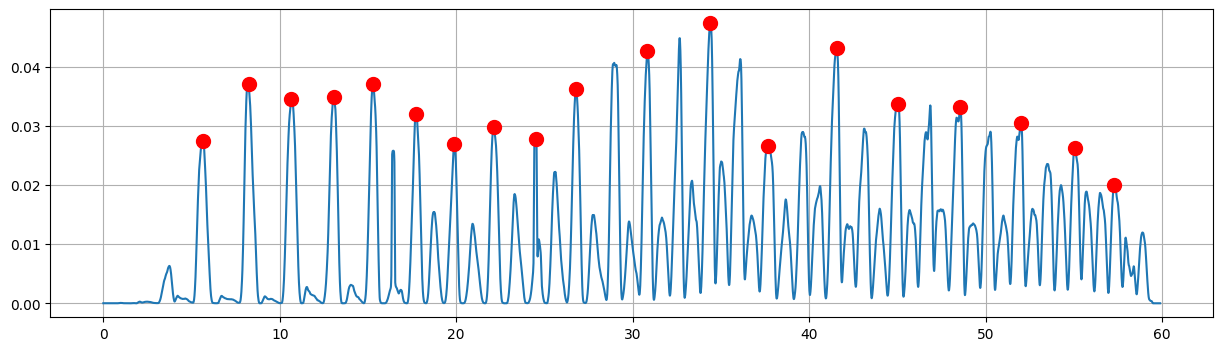

Peak Times: [ 5.65405896  8.23147392 10.65795918 13.04961451 15.30195011 17.7168254
 19.89950113 22.1170068  24.53188209 26.79582766 30.83609977 34.41197279
 37.68598639 41.5753288  45.058322   48.57614512 52.01269841 55.07773243
 57.2952381 ]
Number of Peaks: 19


In [38]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    rms_smooth,
    distance=180,
    prominence=0.012
)

plt.figure(figsize=(15,4))
plt.plot(times, rms_smooth)
plt.plot(times[peaks], rms_smooth[peaks], "ro", markersize=10)
plt.grid()
plt.show()

print("Peak Times:", times[peaks])
print("Number of Peaks:", len(peaks))

In [39]:

total_cycles = len(peaks)

print("Total Breathing Cycles:", total_cycles)

Total Breathing Cycles: 19


In [40]:

cycle_duration = np.diff(times[peaks])

print(cycle_duration)

[2.57741497 2.42648526 2.39165533 2.2523356  2.41487528 2.18267574
 2.21750567 2.41487528 2.26394558 4.04027211 3.57587302 3.27401361
 3.8893424  3.4829932  3.51782313 3.43655329 3.06503401 2.21750567]


In [41]:
avg_cycle = np.mean(cycle_duration)

print(avg_cycle)

2.8689543965734443


In [42]:

breathing_rate = 60/avg_cycle

print("Breathing Frequency =",breathing_rate)


Breathing Frequency = 20.913542603417266


In [43]:

std_cycle=np.std(cycle_duration)

print(std_cycle)

0.6334491876108942


In [44]:
avg_energy = np.mean(rms_smooth)
print("Average RMS Energy:", avg_energy)

Average RMS Energy: 0.0114052256766475


In [45]:
max_energy = np.max(rms_smooth)
print("Maximum RMS Energy:", max_energy)

Maximum RMS Energy: 0.047315083692471185


In [47]:
min_energy = np.min(rms_smooth)
print("Minimum RMS Energy:", min_energy)

Minimum RMS Energy: 0.0


In [49]:
import pandas as pd

results = pd.DataFrame({
    "Parameter": [
        "Audio Duration (s)",
        "Detected Breathing Cycles",
        "Average Cycle Duration (s)",
        "Breathing Frequency (breaths/min)",
        "Rhythm Consistency (STD)",
        "Average RMS Energy",
        "Maximum RMS Energy",
        "Minimum RMS Energy"
    ],
    "Value": [
        librosa.get_duration(y=y, sr=sr),
        total_cycles,
        avg_cycle,
        breathing_rate,
        std_cycle,
        avg_energy,
        max_energy,
        min_energy
    ]
})

print(results)

results.to_csv("Quantitative_Report.csv", index=False)

                           Parameter      Value
0                 Audio Duration (s)  59.904014
1          Detected Breathing Cycles  19.000000
2         Average Cycle Duration (s)   2.868954
3  Breathing Frequency (breaths/min)  20.913543
4           Rhythm Consistency (STD)   0.633449
5                 Average RMS Energy   0.011405
6                 Maximum RMS Energy   0.047315
7                 Minimum RMS Energy   0.000000


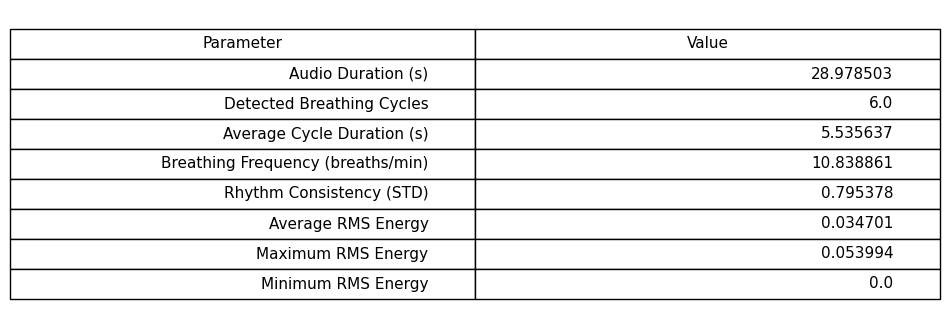

In [48]:
import matplotlib.pyplot as plt
import pandas as pd

# Your dataframe
results = pd.DataFrame({
    "Parameter": [
        "Audio Duration (s)",
        "Detected Breathing Cycles",
        "Average Cycle Duration (s)",
        "Breathing Frequency (breaths/min)",
        "Rhythm Consistency (STD)",
        "Average RMS Energy",
        "Maximum RMS Energy",
        "Minimum RMS Energy"
    ],
    "Value": [
        28.978503,
        6,
        5.535637,
        10.838861,
        0.795378,
        0.034701,
        0.053994,
        0.000000
    ]
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=results.values,
    colLabels=results.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

plt.savefig("quantitative_results.png", dpi=300, bbox_inches='tight')
plt.show()